In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings as wr
wr.filterwarnings('ignore')

In [2]:
df = pd.read_csv('mall customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.shape

(200, 5)

In [4]:
df.drop(['CustomerID','Gender'], axis=1, inplace=True)

In [5]:
df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [6]:
#df = df.rename(columns={'Age': 'age', 'Annual Income (k$)':'income', 'Spending Score (1-100)':'score'})
df.rename(columns={'Age': 'age', 'Annual Income (k$)':'income', 'Spending Score (1-100)':'score'}, inplace=True)

In [7]:
df.head()

,age,income,score
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [8]:
df.shape

(200, 3)

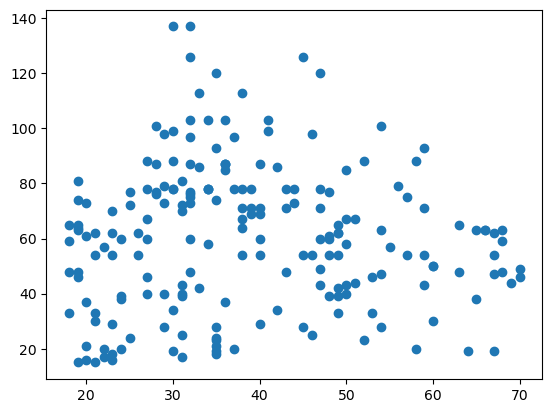

In [9]:
plt.scatter(df.age, df.income)

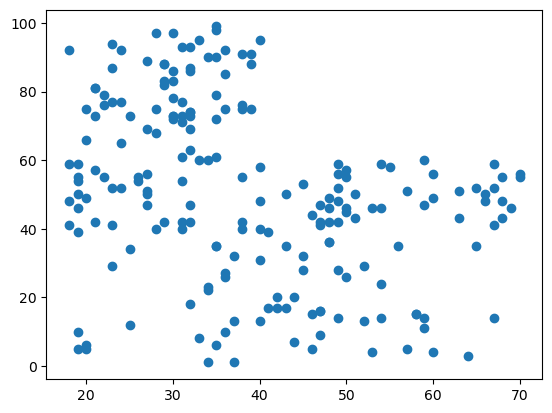

In [10]:
plt.scatter(df.age, df.score)

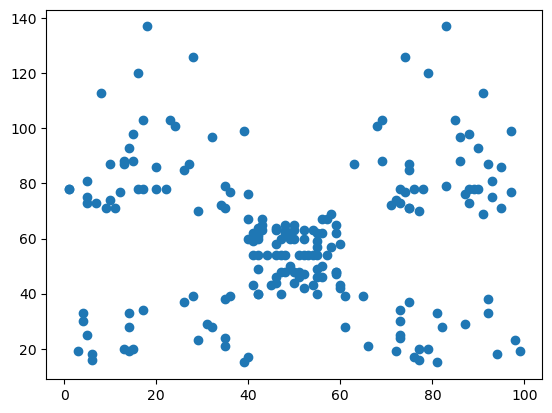

In [11]:
plt.scatter(df.score, df.income)

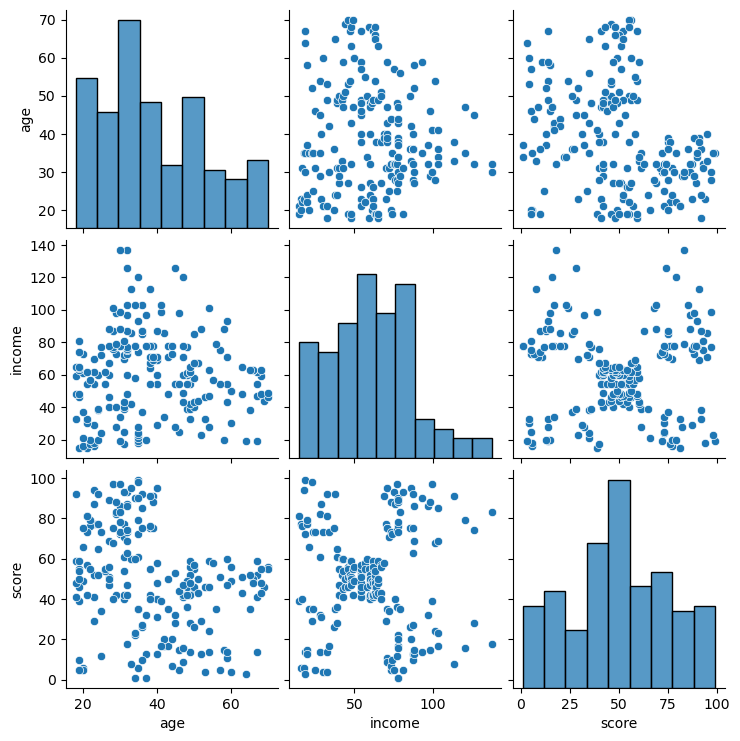

In [12]:
import seaborn as sns
sns.pairplot(df[['age','income','score']])
plt.savefig('image.png')

# KMEANS CLUSTER

Text(0.5, 1.0, 'income and score plot of cutomres')

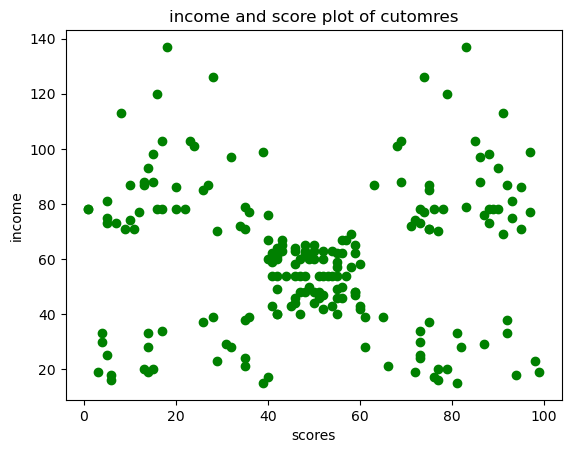

In [14]:
plt.scatter(df.score, df.income, color='green')
plt.xlabel('scores')
plt.ylabel('income')
plt.title('income and score plot of cutomres') #https://prnt.sc/SuRtEtVwydhu

[KMeans Cluster](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)

[Download this Cheatsheet](https://github.com/rashakil-ds/Top-Data-Science-AI-Book-Collection/blob/main/Other%20Docs/Clustering%20Algorithms.pdf)

In [15]:
from sklearn.cluster import KMeans

In [16]:
km = KMeans() # default number of clusters = 8 

In [18]:
# km.fit_predict(df[['score', 'income']]) # training model

In [19]:
km.fit(df[['score', 'income']])

KMeans()

In [20]:
km.predict(df[['score', 'income']])

array([3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1, 1,
       3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 7, 1, 1, 7, 1, 1, 1, 1, 1,
       1, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 2, 7, 2, 7, 2, 5, 2, 5, 2,
       7, 2, 5, 2, 5, 2, 5, 2, 5, 2, 7, 2, 5, 2, 7, 2, 5, 2, 5, 2, 5, 2,
       5, 2, 5, 2, 5, 2, 7, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2,
       5, 2, 5, 2, 0, 6, 0, 6, 0, 6, 0, 6, 0, 6, 0, 6, 0, 6, 0, 6, 0, 6,
       0, 6])

In [21]:
km.cluster_centers_

array([[ 22.        , 109.7       ],
       [ 51.61363636,  47.65909091],
       [ 82.17241379,  78.55172414],
       [ 20.22727273,  25.72727273],
       [ 80.04761905,  25.0952381 ],
       [ 12.68181818,  80.18181818],
       [ 82.        , 109.7       ],
       [ 46.21428571,  63.95238095]])

In [22]:
df['Group1'] = km.predict(df[['score', 'income']])
df.head()

,age,income,score,Group1
0,19,15,39,3
1,21,15,81,4
2,20,16,6,3
3,23,16,77,4
4,31,17,40,3


In [23]:
df.tail()

,age,income,score,Group1
195,35,120,79,6
196,45,126,28,0
197,32,126,74,6
198,32,137,18,0
199,30,137,83,6


In [25]:
df0 = df[df.Group1 == 0]
df1 = df[df.Group1 == 1]
df2 = df[df.Group1 == 2]
df3 = df[df.Group1 == 3]
df4 = df[df.Group1 == 4]
df5 = df[df.Group1 == 5]
df6 = df[df.Group1 == 6]
df7 = df[df.Group1 == 7]

In [26]:
df0.head()

,age,income,score,Group1
180,37,97,32,0
182,46,98,15,0
184,41,99,39,0
186,54,101,24,0
188,41,103,17,0


In [27]:
df0.shape

(10, 4)

In [28]:
centroid = km.cluster_centers_ 
centroid

array([[ 22.        , 109.7       ],
       [ 51.61363636,  47.65909091],
       [ 82.17241379,  78.55172414],
       [ 20.22727273,  25.72727273],
       [ 80.04761905,  25.0952381 ],
       [ 12.68181818,  80.18181818],
       [ 82.        , 109.7       ],
       [ 46.21428571,  63.95238095]])

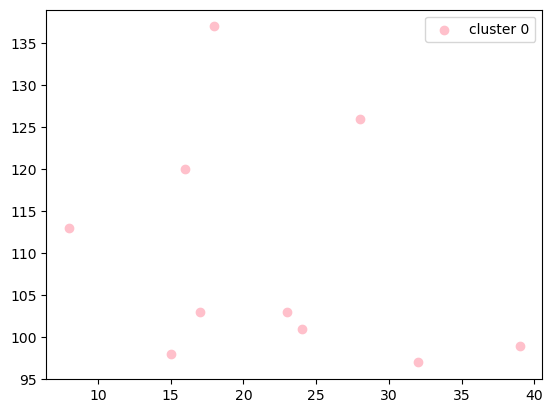

In [30]:
plt.scatter(df0.score, df0.income, color='pink', label='cluster 0')
plt.legend()

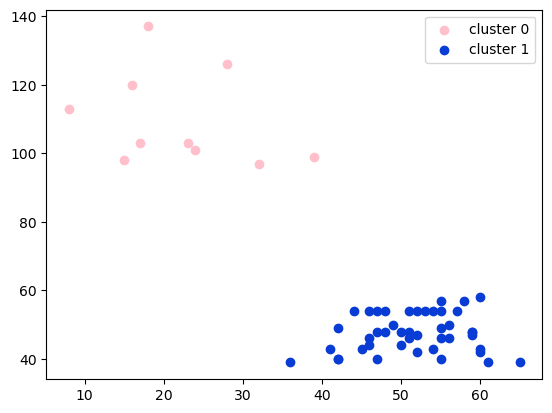

In [31]:
plt.scatter(df0.score, df0.income, color='pink', label='cluster 0')
plt.scatter(df1.score, df1.income, color='#083CD4', label='cluster 1')
plt.legend()

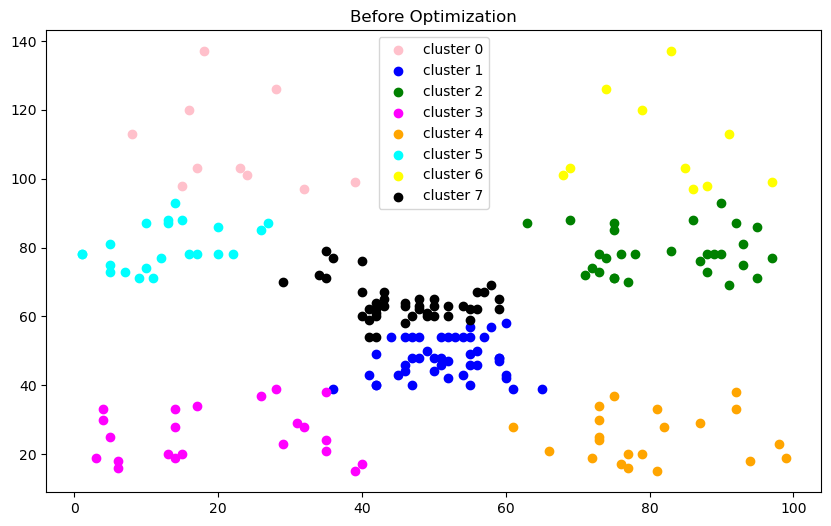

In [32]:
plt.figure(figsize=(10,6))

plt.scatter(df0.score, df0.income, color='pink', label='cluster 0')
plt.scatter(df1.score, df1.income, color='blue', label='cluster 1')
plt.scatter(df2.score, df2.income, color='green', label='cluster 2')
plt.scatter(df3.score, df3.income, color='magenta', label='cluster 3')
plt.scatter(df4.score, df4.income, color='orange', label='cluster 4')
plt.scatter(df5.score, df5.income, color='cyan', label='cluster 5')
plt.scatter(df6.score, df6.income, color='yellow', label='cluster 6')
plt.scatter(df7.score, df7.income, color='black', label='cluster 7')

#plt.scatter(centroid[:, 0], centroid[:,1], color='red', label='centroid')

plt.title('Before Optimization') #https://prnt.sc/oAzguSSV1TNH

plt.legend()

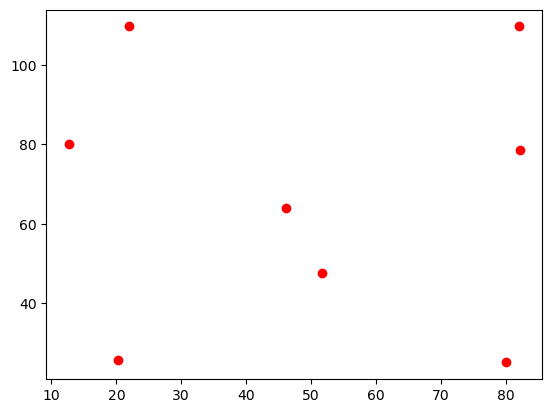

In [33]:
plt.scatter(centroid[:, 0], centroid[:,1], color='red', label='centroid')

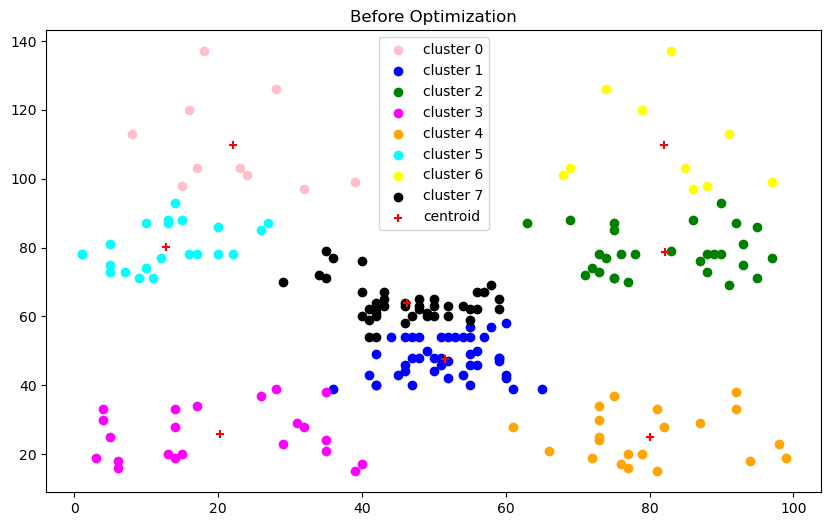

In [34]:
plt.figure(figsize=(10,6))

plt.scatter(df0.score, df0.income, color='pink', label='cluster 0')
plt.scatter(df1.score, df1.income, color='blue', label='cluster 1')
plt.scatter(df2.score, df2.income, color='green', label='cluster 2')
plt.scatter(df3.score, df3.income, color='magenta', label='cluster 3')
plt.scatter(df4.score, df4.income, color='orange', label='cluster 4')
plt.scatter(df5.score, df5.income, color='cyan', label='cluster 5')
plt.scatter(df6.score, df6.income, color='yellow', label='cluster 6')
plt.scatter(df7.score, df7.income, color='black', label='cluster 7')

plt.scatter(centroid[:, 0], centroid[:,1], color='red', label='centroid', marker='+')

plt.title('Before Optimization') #https://prnt.sc/oAzguSSV1TNH

plt.legend()

# Objective Function

Objective function of k-means clustering:
J = ∑_{i=1}^{k} ∑_{x ∈ C_i} ||x - μ_i||^2

Where:
- k is the number of clusters.
- C_i represents the i-th cluster.
- μ_i is the centroid (mean) of cluster C_i.
- ||x - μ_i||^2 represents the squared Euclidean distance between data point x and the centroid μ_i of its assigned cluster.


In [35]:
km.inertia_

25011.839349156588

# Optimizing KMENAS

In [36]:
wcss = []
cluster = range(1,15)

for k in range(1,15):
    km2 = KMeans(n_clusters=k)
    km2.fit(df[['score', 'income']])
    wcss.append(km2.inertia_)

In [37]:
wcss

[269981.28,
 183069.17582751293,
 106348.37306211118,
 73679.78903948836,
 44448.45544793371,
 37233.81451071001,
 30227.606513152015,
 25005.9348059662,
 21838.863692828912,
 19692.557418227767,
 18002.7251004214,
 16055.92273513602,
 14292.543823365122,
 12960.097725081934]

Text(0.5, 0, 'Cluster')

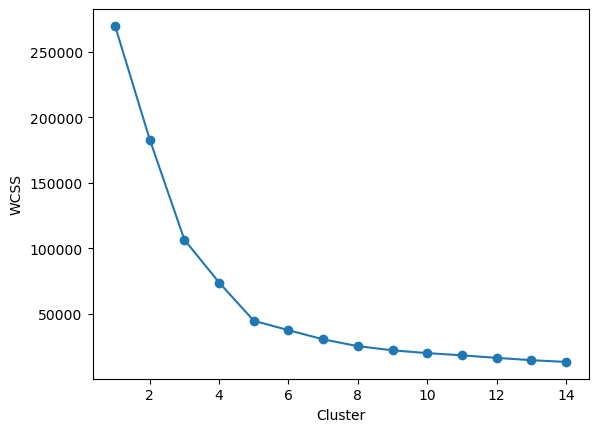

In [38]:
plt.plot(range(1,15), wcss, marker='o') #line plot
plt.ylabel('WCSS')
plt.xlabel('Cluster')

In [ ]:
#!pip install kneed

In [39]:
from kneed import KneeLocator

In [40]:
kn = KneeLocator(cluster, wcss, direction='decreasing', curve='convex')

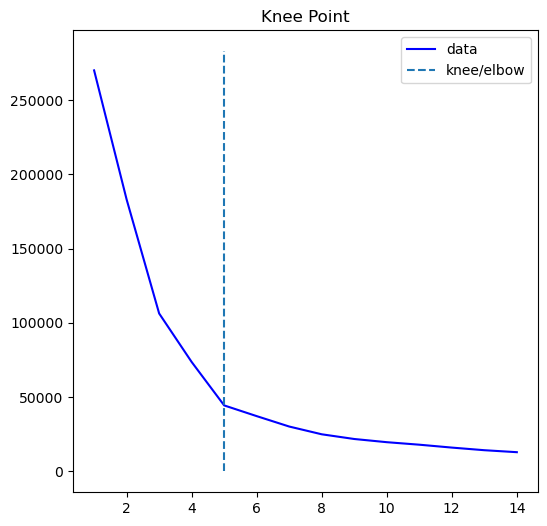

In [41]:
kn.plot_knee()

In [43]:
print('Optimal Number of Cluster is =', kn.knee)

Optimal Number of Cluster is = 5


# After Optimizing

In [44]:
km = KMeans(n_clusters=5) #i know 5 is optimal
df['Group2'] = km.fit_predict(df[['score', 'income']]) #fit_predict()

In [45]:
df.head()

,age,income,score,Group1,Group2
0,19,15,39,3,4
1,21,15,81,4,0
2,20,16,6,3,4
3,23,16,77,4,0
4,31,17,40,3,4


In [46]:
cen = km.cluster_centers_
cen

array([[79.36363636, 25.72727273],
       [49.51851852, 55.2962963 ],
       [82.12820513, 86.53846154],
       [17.11428571, 88.2       ],
       [20.91304348, 26.30434783]])

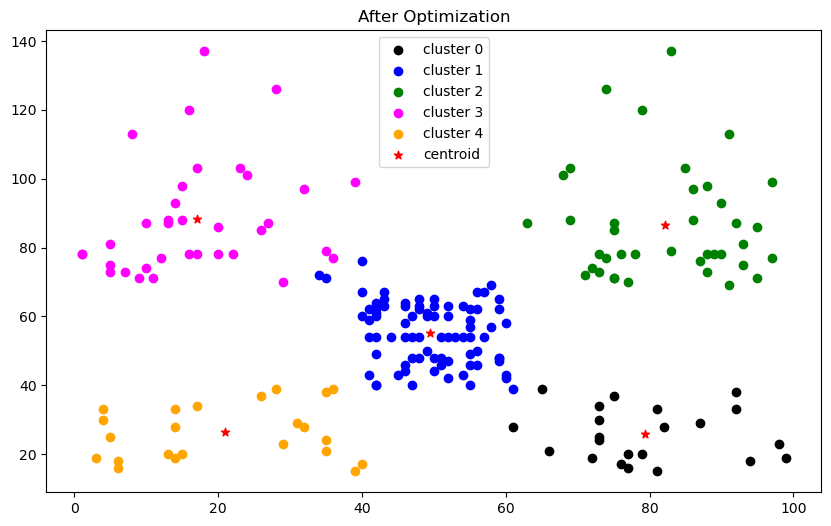

In [47]:
df0 = df[df.Group2 == 0]
df1 = df[df.Group2 == 1]
df2 = df[df.Group2 == 2]
df3 = df[df.Group2 == 3]
df4 = df[df.Group2 == 4]

plt.figure(figsize=(10,6))
plt.scatter(df0.score, df0.income, color='black', label='cluster 0')
plt.scatter(df1.score, df1.income, color='blue', label='cluster 1')
plt.scatter(df2.score, df2.income, color='green', label='cluster 2')
plt.scatter(df3.score, df3.income, color='magenta', label='cluster 3')
plt.scatter(df4.score, df4.income, color='orange', label='cluster 4')

plt.scatter(cen[:, 0], cen[:,1], color='red', label='centroid', marker='*')
plt.title('After Optimization')

plt.legend()